# Energy–Time Parallel Simulation Analysis (Artefact)

This notebook is a artefact made to study the energy and time behaviour of the parallel workload generated by `parallel_simulator_energy`.

We will:
- Describe the experimental context and JSON outputs.
- Load and clean the raw measurements (remove outliers).
- Aggregate per-core results.
- Visualise distributions and scaling behaviour.
- Summarise the main findings.


## 1. Experimental context

The binary produced by $parallel_simulator_energy$ runs a synthetic parallel workload on a multi-core CPU. For each configuration (number of threads, sequential fraction, etc.), it:

- Executes the benchmark multiple times ($n_stat$).
- Measures **energy** (RAPL), **execution time**, **temperature**, and **voltage**.
- Stores all samples in a JSON file.

The goal of this notebook is to take such a JSON result file and perform a reproducible analysis of the scaling properties and variability, while cleaning obvious measurement outliers.


In [10]:
# 2. Imports and helper functions

import json
import statistics

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm


def evaluate_greenup(r, n):
    """Theoretical greenup for parameter r and n cores.

    G(n) = (1 + r) / (1 + r / n)
    """
    return (1 + r) / (1 + r / n)


def calc_rat(sp_n, sp_n_p_1, n):
    """Speedup ratio helper used in scaling analysis.

    Parameters
    ----------
    sp_n : float
        Speedup with n cores.
    sp_n_p_1 : float
        Speedup with n+1 cores.
    n : int
        Current core count.
    """
    r = (sp_n_p_1 - sp_n) / (sp_n / n - sp_n_p_1 / (n + 1))
    return r


def calc_sp(ref, core_n):
    """Compute ideal speedup assuming linear scaling."""
    return ref / core_n


def clean_outliers(x, lower_quantile=0.05, upper_quantile=0.95):
    """Remove outliers based on quantiles.

    Returns the filtered Series and a boolean mask that can be
    reused on aligned arrays (e.g. time and energy).
    """
    x = pd.Series(x)
    lower = x.quantile(lower_quantile)
    upper = x.quantile(upper_quantile)
    mask = (x >= lower) & (x <= upper)
    return x[mask], mask


def med(values):
    """Median of a list/array (wrapper around statistics.median)."""
    return statistics.median(values)


def load_clean(filename):
    """Load a JSON result file and clean energy/time samples.

    The JSON is expected to contain the keys:
    - "energy": dict mapping experiment name -> list of samples
    - "time":   dict with the same keys as "energy"
    - "voltage": dict of voltage samples per experiment
    - "temperature": dict of temperature samples per experiment
    - "params": global simulation parameters
    """
    with open(filename, "r") as f:
        data = json.load(f)

    energy_clean = {}
    time_clean = {}
    for exp_name, val in data["energy"].items():
        energy_clean_tmp, mask = clean_outliers(val)
        energy_clean[exp_name] = energy_clean_tmp
        time_clean_tmp = np.array(data["time"][exp_name])[mask]
        time_clean[exp_name] = time_clean_tmp

    voltage = data["voltage"]
    temperature = data["temperature"]
    parameters = data["params"]
    return energy_clean, time_clean, voltage, temperature, parameters


def load_raw(filename):
    """Load raw energy samples and corresponding core counts.

    Returns
    -------
    energy : list of list[float]
        Raw energy samples per experiment.
    cores : list[int]
        Core count per experiment, parsed from the experiment name.
    """
    with open(filename, "r") as f:
        data = json.load(f)
    energy = []
    cores = []
    for exp_name, val in data["energy"].items():
        energy.append(val)
        cores.append(int(exp_name.split("_")[0]))
    return energy, cores


def load_exlude_temp(filename):
    """Load energy samples restricted to a fixed reference temperature.

    The function identifies the median temperature of the first
    experiment and only keeps energy samples whose corresponding
    temperature matches this value.
    """
    with open(filename, "r") as f:
        data = json.load(f)
    n_cores = len(data["params"]["n_cores"])
    cores = []
    energy = [[] for _ in range(n_cores)]
    fixed_temp = int(med(list(data["temperature"].values())[0]))
    for exp_name, vals in data["energy"].items():
        cur_core = int(exp_name.split("_")[0])
        for i, v in enumerate(vals):
            coresp_temp = data["temperature"][exp_name][i]
            if coresp_temp == fixed_temp:
                energy[cur_core - 1].append(v)
        cores.append(cur_core)
    return energy, cores


## 2. Loading and cleaning a result file

1. Select a JSON result file produced by the C binary.
2. Load raw energy/time samples.
3. Clean outliers (per experiment name).
4. Compute summary statistics (median, mean, variance, etc.).

In [11]:
# Example: load and clean one JSON result file

RESULT_PATH = "./resultats/sim1.json"  # adjust to your actual output file

energy_clean, time_clean, voltage, temperature, params = load_clean(RESULT_PATH)
params


{'date': '2026-03-04 15:17:02',
 'arch': 'HSW',
 'sensor': 'PKG',
 'freq': 2.4,
 'n_work': 100000000,
 'n_stat': 10,
 'n_cores': [1, 2, 3, 4, 5, 6, 7, 8],
 'seq_fraction': 0}

## 3. Distribution analysis

Here we inspect the distribution of energy and time for a given configuration (e.g. fixed number of cores and sequential fraction), similarly to $avec_nettoyage.ipynb$.


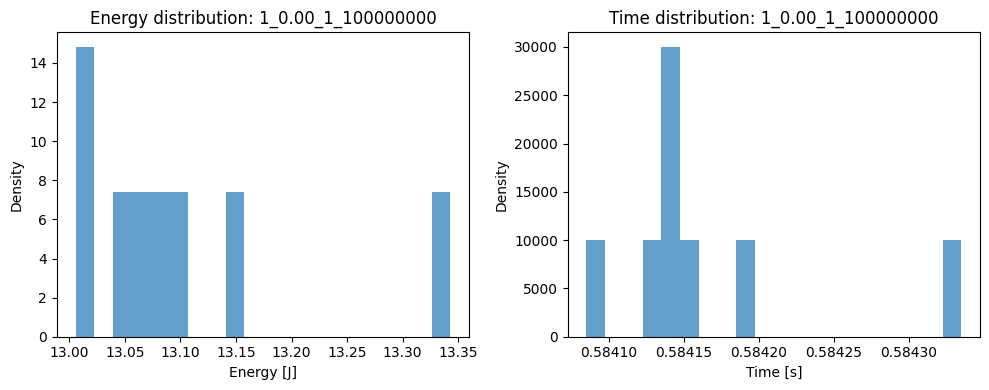

In [12]:
# Choose one experiment key, e.g. "4_0.00_1_100000000"

example_key = sorted(energy_clean.keys())[0]
e_vals = np.array(energy_clean[example_key])
t_vals = np.array(time_clean[example_key])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(e_vals, bins=20, density=True, alpha=0.7)
axes[0].set_title(f"Energy distribution: {example_key}")
axes[0].set_xlabel("Energy [J]")
axes[0].set_ylabel("Density")

axes[1].hist(t_vals, bins=20, density=True, alpha=0.7)
axes[1].set_title(f"Time distribution: {example_key}")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()


## 4. Scaling of time with the number of cores

Shows how the times values are following Amdahl's model.

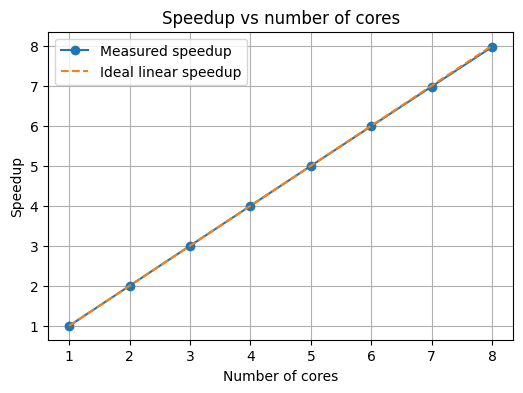

In [13]:
# Compute median energy/time and speedup per core count

core_counts = []
median_time = []
median_energy = []

for key in sorted(energy_clean.keys(), key=lambda k: int(k.split("_")[0])):
    ncores = int(key.split("_")[0])
    core_counts.append(ncores)
    median_time.append(med(time_clean[key]))
    median_energy.append(med(energy_clean[key]))

core_counts = np.array(core_counts)
median_time = np.array(median_time)
median_energy = np.array(median_energy)

# Use 1-core time as reference for speedup
t1 = median_time[core_counts == 1][0]
speedup = t1 / median_time

plt.figure(figsize=(6, 4))
plt.plot(core_counts, speedup, "o-", label="Measured speedup")
plt.plot(core_counts, core_counts, "--", label="Ideal linear speedup")
plt.xlabel("Number of cores")
plt.ylabel("Speedup")
plt.legend()
plt.title("Speedup vs number of cores")
plt.grid(True)
plt.show()


## 5. Energy scaling ("greenup")

We now study how **energy consumption** scales with the number of cores. The *greenup*, defined analogously to speedup but for energy:

- Let \(E_1\) be the median energy with 1 core.
- Let \(E_n\) be the median energy with \(n\) cores.
- The **greenup** for \(n\) cores is

$$
     G(n) = \frac{E_1}{E_n} 
$$

Values of \(G(n) > 1\) indicate that using \(n\) cores is more energy-efficient than 1 core for the same amount of work; \(G(n) < 1\) indicates an energy penalty.

### 5.1 Greenup model and asymptote

We now fit a simple *energy greenup model* based on the ratio parameter $r$ (as in the detailed notebook):

- For each adjacent pair of core counts $n$ and $n+1$, we estimate $r$ from the change in median greenup.
- We then summarise all these ratios into a single parameter (here: median $r$).
- The corresponding theoretical greenup curve is
  $ G(n) = \frac{1 + r}{1 + r / n} $
  whose horizontal asymptote as $n \to \infty$ is $1 + r$.

The figure below overlays:


- The **measured median greenup** per core.
- The **model greenup curve** $G(n)$.
- The **ideal speedup** line (linear in the number of cores).
- The **asymptotic greenup** level $1 + r$ as a horizontal dashed line.

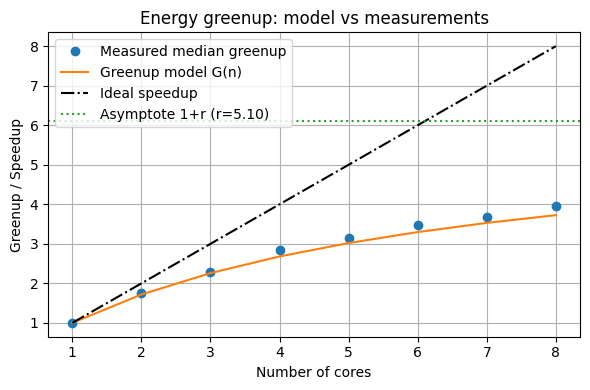

In [16]:
# Greenup model: fit r and plot model vs measurements

# Build per-core lists of greenup samples (energy-based)
core_keys = sorted(energy_clean.keys(), key=lambda k: int(k.split("_")[0]))
cores = np.array([int(k.split("_")[0]) for k in core_keys])

# Reference energy = median energy at 1 core
ref_energy = med(energy_clean[core_keys[0]])

greenup_samples = []  # list of lists per core
for key in core_keys:
    e_vals = np.array(energy_clean[key], dtype=float)
    g_vals = ref_energy / e_vals
    greenup_samples.append(list(g_vals))

# Estimate r from ratios between successive core counts
ratios = []
for i in range(len(greenup_samples) - 1):
    n = i + 1  # core count for position i
    g_n = med(greenup_samples[i])
    for g_n1 in greenup_samples[i + 1]:
        ratios.append(calc_rat(g_n, g_n1, n))

# Optionally clean extreme ratios using the same quantile-based filter
ratios_clean, _ = clean_outliers(ratios)

# Single model parameter r_hat (median of cleaned ratios)
r_hat = float(med(ratios_clean))

# Median measured greenup per core
median_greenup = np.array([med(g) for g in greenup_samples])

# Theoretical model curve and asymptote
model_greenup = np.array([evaluate_greenup(r_hat, int(n)) for n in cores])
ideal_speedup = cores.astype(float)  # reference linear speedup
asymptote = 1.0 + r_hat

plt.figure(figsize=(6, 4))
plt.plot(cores, median_greenup, "o", label="Measured median greenup", color="C0")
plt.plot(cores, model_greenup, "-", label="Greenup model G(n)", color="C1")
plt.plot(cores, ideal_speedup, "k-.", label="Ideal speedup", linewidth=1.5)
plt.axhline(y=asymptote, linestyle=":", color="C2", label=f"Asymptote 1+r (r={r_hat:.2f})")

plt.xlabel("Number of cores")
plt.ylabel("Greenup / Speedup")
plt.title("Energy greenup: model vs measurements")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Conclusion

This notebook provides artefact containing:

- Helper functions to load → clean → analyse → visualise.
- Sections introducing experimental context, data preparation, distribution analysis, and scaling behaviour.